# Basis Arbitrage Baseline Analysis (Chapter 2)


In [12]:
from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')

## 1) 選擇回測 Run

In [13]:
RUN_DIR_NAME: str | None = None  # 例如: '20260313_010252'

repo_root = Path.cwd()
while repo_root.parent != repo_root and not (repo_root / 'out' / 'build').exists():
    repo_root = repo_root.parent

logs_dir = repo_root / 'out' / 'build' / 'x64-release' / 'QTrading.Service' / 'logs'
config_path = repo_root / 'research' / 'basis_arbitrage' / 'config' / 'basis_arbitrage_v1.json'

if RUN_DIR_NAME is None:
    run_dirs = [p for p in logs_dir.iterdir() if p.is_dir()]
    if not run_dirs:
        raise RuntimeError(f'No run dirs under: {logs_dir}')
    run_dir = max(run_dirs, key=lambda p: p.stat().st_mtime)
else:
    run_dir = logs_dir / RUN_DIR_NAME

print('repo_root =', repo_root)
print('logs_dir  =', logs_dir)
print('run_dir   =', run_dir)
print('config    =', config_path)

repo_root = d:\QTrading.Cpp
logs_dir  = d:\QTrading.Cpp\out\build\x64-release\QTrading.Service\logs
run_dir   = d:\QTrading.Cpp\out\build\x64-release\QTrading.Service\logs\20260313_010252
config    = d:\QTrading.Cpp\research\basis_arbitrage\config\basis_arbitrage_v1.json


## 2) 讀取 Arrow Logs

這一步會把常用事件表都載入 DataFrame，並顯示 row count。

In [14]:
def read_arrow_df(path: Path) -> pd.DataFrame | None:
    if not path.exists() or path.stat().st_size == 0:
        return None
    with pa.memory_map(str(path), 'r') as source:
        table = pa.ipc.RecordBatchFileReader(source).read_all()
    return table.to_pandas()

def load_tables(run_dir: Path) -> dict[str, pd.DataFrame | None]:
    names = [
        'Account.arrow',
        'AccountEvent.arrow',
        'OrderEvent.arrow',
        'Position.arrow',
        'PositionEvent.arrow',
        'MarketEvent.arrow',
        'FundingEvent.arrow',
        'RunMetadata.arrow',
    ]
    out = {}
    for n in names:
        out[n] = read_arrow_df(run_dir / n)
    return out

tables = load_tables(run_dir)

rows = []
for name, df in tables.items():
    rows.append({
        'table': name,
        'exists': df is not None,
        'rows': 0 if df is None else len(df),
        'columns': [] if df is None else list(df.columns),
    })

status_df = pd.DataFrame(rows)
status_df

,table,exists,rows,columns
0,Account.arrow,True,1568097,"[timestamp, balance, unreal_pnl, equity, perp_..."
1,AccountEvent.arrow,True,1568277,"[ts, run_id, step_seq, event_seq, request_id, ..."
2,OrderEvent.arrow,True,213,"[ts, run_id, step_seq, event_seq, request_id, ..."
3,Position.arrow,True,3136190,"[timestamp, id, order_id, symbol, instrument_t..."
4,PositionEvent.arrow,True,796,"[ts, run_id, step_seq, event_seq, request_id, ..."
5,MarketEvent.arrow,True,3158622,"[ts, run_id, step_seq, event_seq, symbol, has_..."
6,FundingEvent.arrow,True,3182,"[ts, run_id, step_seq, event_seq, symbol, inst..."
7,RunMetadata.arrow,True,1,"[ts, run_id, strategy_name, strategy_version, ..."


## 3) 基本績效摘要

核心指標解讀：
- `return_pct` / `annualized_return_pct`：整體報酬
- `funding_sum`：直接 funding 收益
- `total_fees`：交易成本
- `residual_price_basis`：非 funding 的損益（價格/基差漂移 + 其他）
- `max_drawdown_pct`：資產曲線最大回撤

In [15]:
acc = tables['Account.arrow']
ae = tables['AccountEvent.arrow']
oe = tables['OrderEvent.arrow']
fe = tables['FundingEvent.arrow']

if acc is None or len(acc) == 0:
    raise RuntimeError('Account.arrow is empty; cannot compute baseline summary.')

acc = acc.copy()
acc['timestamp'] = pd.to_numeric(acc['timestamp'], errors='coerce')
acc['dt'] = pd.to_datetime(acc['timestamp'], unit='ms', utc=True)
acc['equity'] = pd.to_numeric(acc['total_ledger_value'], errors='coerce')
acc = acc.dropna(subset=['timestamp', 'equity']).sort_values('timestamp').reset_index(drop=True)

start_equity = float(acc['equity'].iloc[0])
end_equity = float(acc['equity'].iloc[-1])
wallet_delta = end_equity - start_equity
return_pct = (end_equity / start_equity - 1.0) * 100.0

days = max((acc['timestamp'].iloc[-1] - acc['timestamp'].iloc[0]) / 1000 / 86400, 1e-12)
annualized_return_pct = ((end_equity / start_equity) ** (365.0 / days) - 1.0) * 100.0

rolling_peak = acc['equity'].cummax()
drawdown = acc['equity'] / rolling_peak - 1.0
max_drawdown_pct = float(drawdown.min() * 100.0)

funding_sum = 0.0
funding_positive_sum = 0.0
funding_negative_sum = 0.0
funding_events = 0
if fe is not None and len(fe) > 0 and 'funding' in fe.columns:
    f = pd.to_numeric(fe['funding'], errors='coerce').fillna(0.0)
    funding_sum = float(f.sum())
    funding_positive_sum = float(f[f > 0].sum())
    funding_negative_sum = float(f[f < 0].sum())
    funding_events = int(len(fe))

total_fees = 0.0
fill_count = 0
taker_ratio = np.nan
if oe is not None and len(oe) > 0:
    o = oe.copy()
    if 'event_type' in o.columns:
        fills = o[o['event_type'] == 3].copy()
    else:
        fills = o.copy()
    fill_count = int(len(fills))
    if 'fee' in fills.columns:
        total_fees = float(pd.to_numeric(fills['fee'], errors='coerce').fillna(0.0).sum())
    if 'is_taker' in fills.columns and len(fills) > 0:
        taker_ratio = float(pd.to_numeric(fills['is_taker'], errors='coerce').fillna(0.0).mean())

residual_price_basis = wallet_delta - funding_sum + total_fees

summary = pd.DataFrame([
    {'metric': 'start_equity', 'value': start_equity},
    {'metric': 'end_equity', 'value': end_equity},
    {'metric': 'wallet_delta', 'value': wallet_delta},
    {'metric': 'return_pct', 'value': return_pct},
    {'metric': 'annualized_return_pct', 'value': annualized_return_pct},
    {'metric': 'max_drawdown_pct', 'value': max_drawdown_pct},
    {'metric': 'funding_sum', 'value': funding_sum},
    {'metric': 'funding_positive_sum', 'value': funding_positive_sum},
    {'metric': 'funding_negative_sum', 'value': funding_negative_sum},
    {'metric': 'total_fees', 'value': total_fees},
    {'metric': 'residual_price_basis', 'value': residual_price_basis},
    {'metric': 'fill_count', 'value': fill_count},
    {'metric': 'funding_events', 'value': funding_events},
    {'metric': 'taker_ratio', 'value': taker_ratio},
    {'metric': 'backtest_days', 'value': days},
])
summary

,metric,value
0,start_equity,1.000000e+08
1,end_equity,1.170976e+08
2,wallet_delta,1.709755e+07
3,return_pct,1.709755e+01
4,annualized_return_pct,5.225737e+00
5,max_drawdown_pct,-8.384835e-01
6,funding_sum,1.790282e+05
7,funding_positive_sum,1.858623e+05
8,funding_negative_sum,-6.834088e+03
9,total_fees,1.158689e+04


## 4) Equity 與 Drawdown 視覺化

看法：
- Equity 線是否平滑上升
- Drawdown 是否過深且回復時間過長

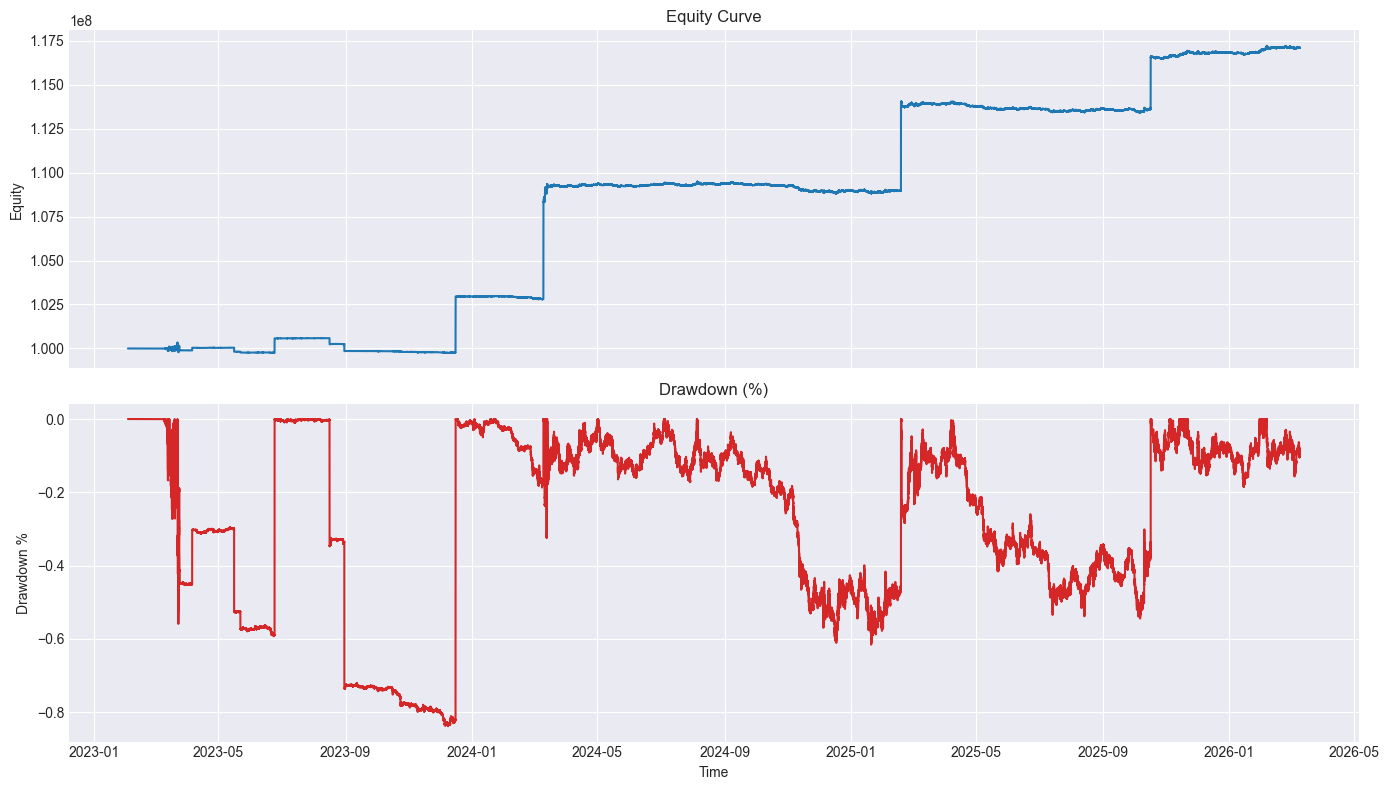

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(acc['dt'], acc['equity'], color='tab:blue')
axes[0].set_title('Equity Curve')
axes[0].set_ylabel('Equity')

axes[1].plot(acc['dt'], drawdown * 100.0, color='tab:red')
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown %')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

## 5) Basis / Mark-Index 結構

重點：
- `trade_basis_bps`：perp trade vs spot trade 的基差
- `mark_index_bps`：perp mark vs perp index 的偏離（你剛加入 guard 的核心）

實務上：
- `mark_index_bps` 長時間偏大，代表風險環境不穩定
- guard 的 soft/hard 門檻是否合理，先看這裡

In [17]:
mkt = tables['MarketEvent.arrow']
if mkt is None or len(mkt) == 0:
    raise RuntimeError('MarketEvent.arrow is empty; cannot analyze basis structure.')

m = mkt.copy()
m['ts'] = pd.to_numeric(m['ts'], errors='coerce')
m['close'] = pd.to_numeric(m['close'], errors='coerce')
m['mark_price'] = pd.to_numeric(m.get('mark_price', np.nan), errors='coerce')
m['index_price'] = pd.to_numeric(m.get('index_price', np.nan), errors='coerce')

for c in ['has_kline', 'has_mark_price', 'has_index_price', 'step_seq', 'event_seq']:
    if c in m.columns:
        m[c] = pd.to_numeric(m[c], errors='coerce')

m = m.dropna(subset=['ts', 'symbol']).copy()
m = m[m['symbol'].isin(['BTCUSDT_SPOT', 'BTCUSDT_PERP'])].copy()

# Keep the latest event per (symbol, ts).
sort_cols = ['ts'] + [c for c in ['step_seq', 'event_seq'] if c in m.columns]
m = m.sort_values(sort_cols)
m = m.groupby(['symbol', 'ts'], as_index=False).tail(1).copy()

# Use only rows backed by real kline bars and valid close prices.
if 'has_kline' in m.columns:
    m = m[m['has_kline'].fillna(0) > 0].copy()
m = m[m['close'] > 0].copy()

spot = m[m['symbol'] == 'BTCUSDT_SPOT'][['ts', 'close']].rename(columns={'close': 'spot_close'})
perp_cols = ['ts', 'close', 'mark_price', 'index_price'] + [c for c in ['has_mark_price', 'has_index_price'] if c in m.columns]
perp = m[m['symbol'] == 'BTCUSDT_PERP'][perp_cols].rename(columns={'close': 'perp_close'})

if 'has_mark_price' in perp.columns:
    perp.loc[perp['has_mark_price'].fillna(0) <= 0, 'mark_price'] = np.nan
if 'has_index_price' in perp.columns:
    perp.loc[perp['has_index_price'].fillna(0) <= 0, 'index_price'] = np.nan

basis_df = spot.merge(
    perp[['ts', 'perp_close', 'mark_price', 'index_price']],
    on='ts',
    how='inner'
).sort_values('ts').reset_index(drop=True)

# Drop invalid merged prices to avoid fake -10000 bps artifacts.
basis_df = basis_df[(basis_df['spot_close'] > 0) & (basis_df['perp_close'] > 0)].copy()

basis_df['dt'] = pd.to_datetime(basis_df['ts'], unit='ms', utc=True)
basis_df['trade_basis_bps'] = (basis_df['perp_close'] - basis_df['spot_close']) / basis_df['spot_close'] * 10000.0
basis_df['mark_index_bps'] = np.where(
    basis_df['index_price'] > 0,
    (basis_df['mark_price'] - basis_df['index_price']) / basis_df['index_price'] * 10000.0,
    np.nan,
)

basis_df[['dt', 'spot_close', 'perp_close', 'mark_price', 'index_price', 'trade_basis_bps', 'mark_index_bps']].head()



,dt,spot_close,perp_close,mark_price,index_price,trade_basis_bps,mark_index_bps
0,2023-03-10 00:00:00+00:00,20359.90,20344.3,20346.352556,20360.168602,-7.662120,-6.785821
1,2023-03-10 00:04:00+00:00,20350.30,20336.4,20336.500000,20351.179844,-6.830366,-7.213264
2,2023-03-10 00:11:00+00:00,20336.36,20320.0,20321.896962,20337.573763,-8.044704,-7.708295
3,2023-03-10 00:12:00+00:00,20325.98,20312.8,20312.800000,20325.491828,-6.484312,-6.244291
4,2023-03-10 00:14:00+00:00,20317.05,20305.1,20305.300000,20319.598868,-5.881759,-7.036983


In [18]:
basis_stats = basis_df[['trade_basis_bps', 'mark_index_bps']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
basis_stats

,count,mean,std,min,1%,5%,50%,95%,99%,max
trade_basis_bps,1175868.0,-2.471595,4.263455,-234.757835,-6.628327,-5.938743,-4.075436,7.275390,10.375812,167.375201
mark_index_bps,1175868.0,-2.273911,3.927231,-33.828168,-6.411217,-5.640892,-3.772120,6.830183,9.825153,100.309248


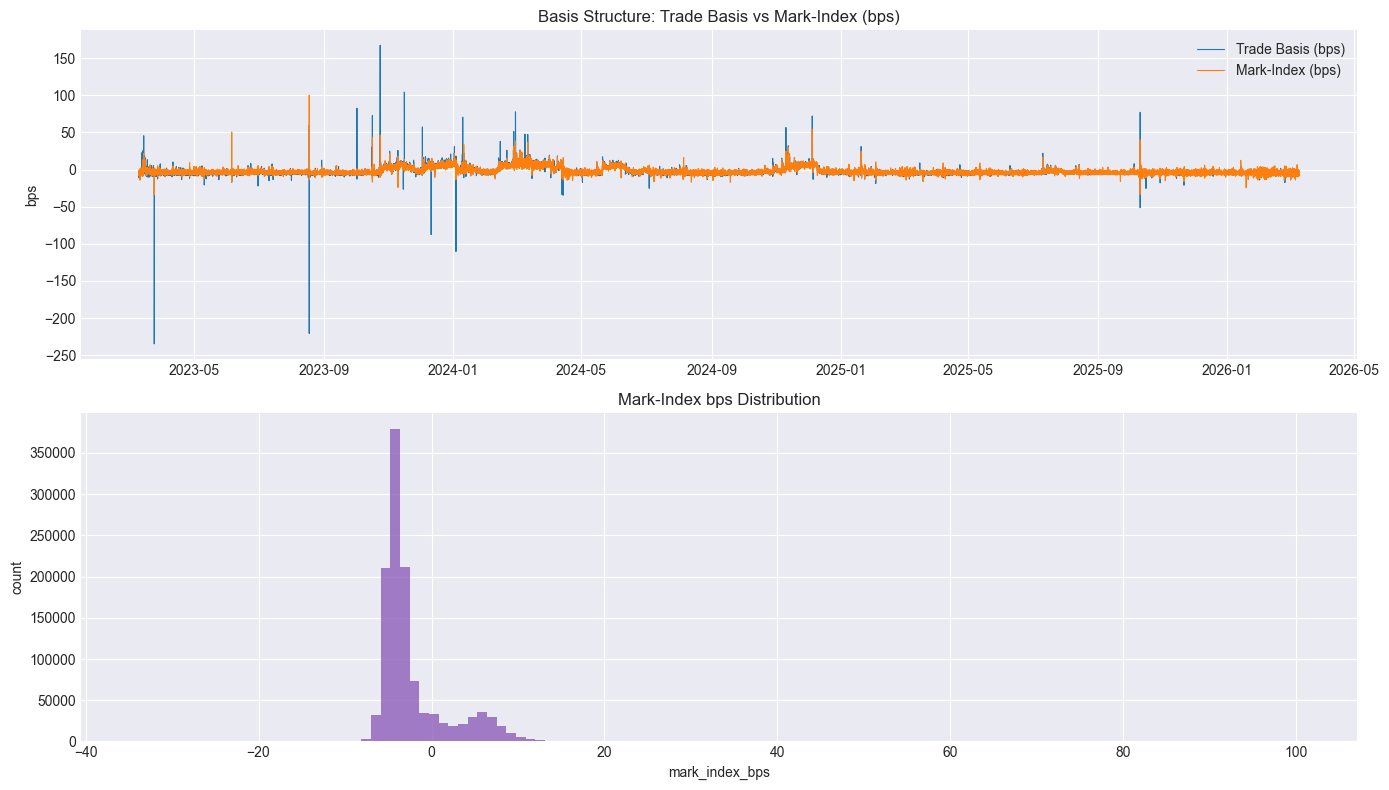

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(basis_df['dt'], basis_df['trade_basis_bps'], linewidth=0.8, label='Trade Basis (bps)')
axes[0].plot(basis_df['dt'], basis_df['mark_index_bps'], linewidth=0.8, label='Mark-Index (bps)')
axes[0].set_title('Basis Structure: Trade Basis vs Mark-Index (bps)')
axes[0].set_ylabel('bps')
axes[0].legend()

mi = basis_df['mark_index_bps'].dropna()
axes[1].hist(mi, bins=120, color='tab:purple', alpha=0.85)
axes[1].set_title('Mark-Index bps Distribution')
axes[1].set_xlabel('mark_index_bps')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()



## 6) Funding 事件品質

看法：
- 正/負 funding 佔比是否健康
- 負 funding 是否集中在某些時段
- funding 累積曲線是否平滑

,metric,value
0,events,3182.000000
1,positive_events,2838.000000
2,negative_events,344.000000
3,positive_ratio,0.891892
4,avg_funding,56.262795
5,median_funding,35.218897
6,sum_funding,179028.214439


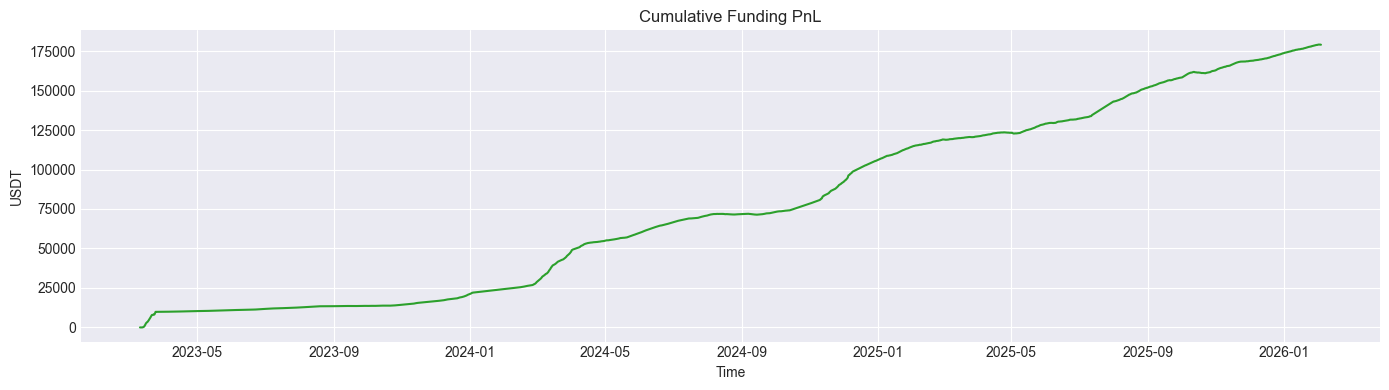

In [20]:
if fe is None or len(fe) == 0:
    print('FundingEvent is empty.')
else:
    f = fe.copy()
    f['ts'] = pd.to_numeric(f['ts'], errors='coerce')
    f['funding'] = pd.to_numeric(f['funding'], errors='coerce').fillna(0.0)
    f['dt'] = pd.to_datetime(f['ts'], unit='ms', utc=True)
    f = f.sort_values('ts').reset_index(drop=True)
    f['cum_funding'] = f['funding'].cumsum()

    funding_quality = pd.DataFrame([
        {'metric': 'events', 'value': len(f)},
        {'metric': 'positive_events', 'value': int((f['funding'] > 0).sum())},
        {'metric': 'negative_events', 'value': int((f['funding'] < 0).sum())},
        {'metric': 'positive_ratio', 'value': float((f['funding'] > 0).mean())},
        {'metric': 'avg_funding', 'value': float(f['funding'].mean())},
        {'metric': 'median_funding', 'value': float(f['funding'].median())},
        {'metric': 'sum_funding', 'value': float(f['funding'].sum())},
    ])
    display(funding_quality)

    plt.figure(figsize=(14, 4))
    plt.plot(f['dt'], f['cum_funding'], color='tab:green')
    plt.title('Cumulative Funding PnL')
    plt.xlabel('Time')
    plt.ylabel('USDT')
    plt.tight_layout()
    plt.show()

## 7) 執行品質（Fees / Taker / Turnover）

看法：
- 高 fees 是否由過度 rebalancing 造成
- taker ratio 偏高時，通常成本壓力更大
- turnover 很高但報酬沒放大，通常代表 execution 需要調整

C:\Users\Kenneth\AppData\Local\Temp\2\ipykernel_10424\1717414326.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  fills['month'] = fills['dt'].dt.to_period('M').astype(str)


,metric,value
0,fill_count,1.800000e+02
1,total_turnover,1.736233e+07
2,avg_fill_notional,9.645741e+04
3,total_fees,1.158689e+04
4,avg_fee_bps,7.472222e+00
5,taker_ratio,9.944444e-01


,month,turnover,fees,fills
0,2023-03,1.612880e+07,10661.737494,124
1,2023-04,2.240713e+04,16.805114,2
2,2023-05,6.632965e+04,49.746688,4
3,2023-06,4.785321e+04,35.890024,2
4,2023-08,4.507188e+04,33.803684,4
5,2023-12,2.453301e+04,18.399823,2
6,2024-03,7.698662e+05,577.400013,32
7,2025-02,1.698581e+05,127.383127,8
8,2025-10,8.761052e+04,65.719152,2


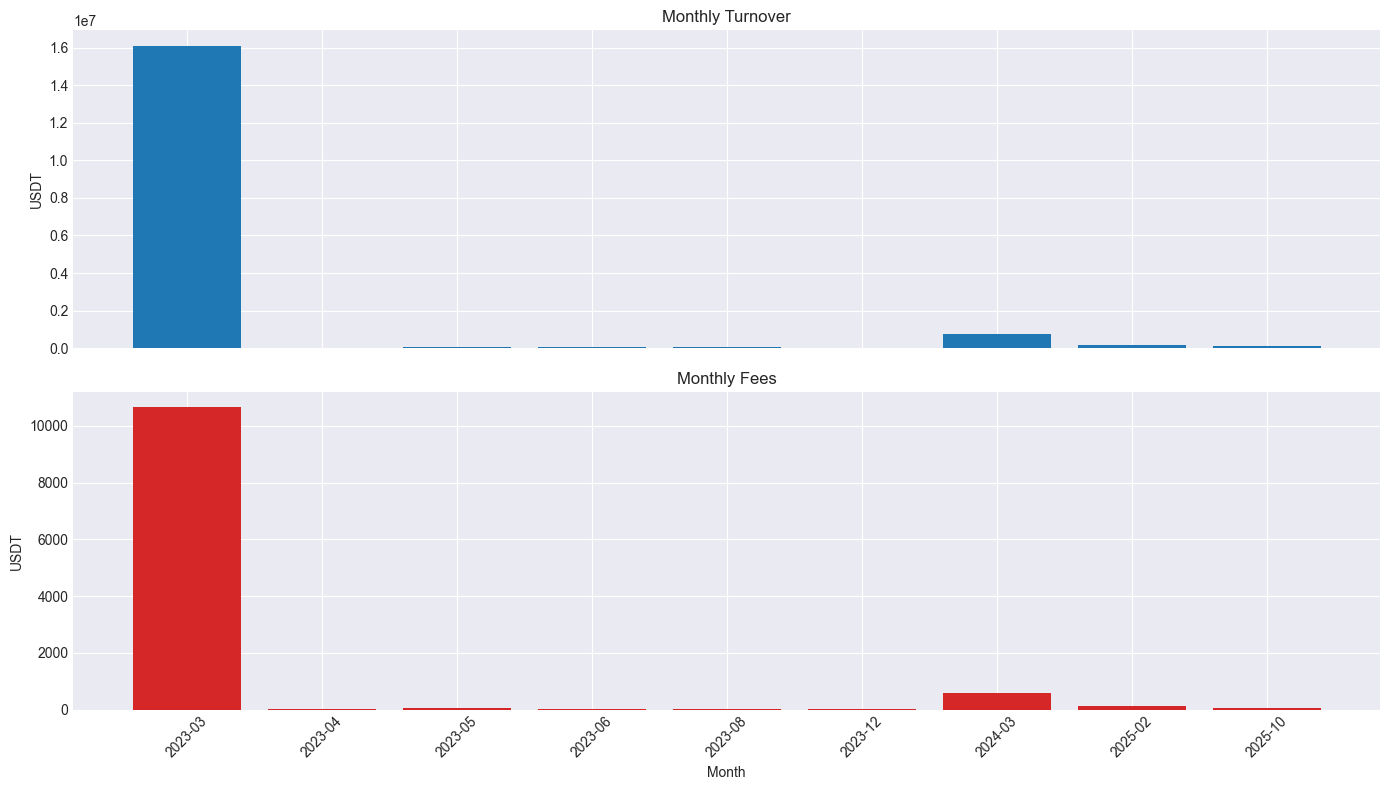

In [21]:
if oe is None or len(oe) == 0:
    print('OrderEvent is empty.')
else:
    fills = oe[oe['event_type'] == 3].copy() if 'event_type' in oe.columns else oe.copy()
    fills['ts'] = pd.to_numeric(fills['ts'], errors='coerce')
    fills['dt'] = pd.to_datetime(fills['ts'], unit='ms', utc=True)
    fills['exec_qty'] = pd.to_numeric(fills['exec_qty'], errors='coerce').fillna(0.0)
    fills['exec_price'] = pd.to_numeric(fills['exec_price'], errors='coerce').fillna(0.0)
    fills['fee'] = pd.to_numeric(fills['fee'], errors='coerce').fillna(0.0)
    fills['fill_notional'] = (fills['exec_qty'] * fills['exec_price']).abs()
    fills['fee_bps'] = np.where(fills['fill_notional'] > 1e-12, fills['fee'] / fills['fill_notional'] * 10000.0, np.nan)
    fills['month'] = fills['dt'].dt.to_period('M').astype(str)

    exec_quality = pd.DataFrame([
        {'metric': 'fill_count', 'value': int(len(fills))},
        {'metric': 'total_turnover', 'value': float(fills['fill_notional'].sum())},
        {'metric': 'avg_fill_notional', 'value': float(fills['fill_notional'].mean()) if len(fills) else np.nan},
        {'metric': 'total_fees', 'value': float(fills['fee'].sum())},
        {'metric': 'avg_fee_bps', 'value': float(fills['fee_bps'].mean())},
        {'metric': 'taker_ratio', 'value': float(pd.to_numeric(fills['is_taker'], errors='coerce').fillna(0.0).mean()) if 'is_taker' in fills.columns else np.nan},
    ])
    display(exec_quality)

    monthly = fills.groupby('month', as_index=False).agg(
        turnover=('fill_notional', 'sum'),
        fees=('fee', 'sum'),
        fills=('fill_notional', 'size')
    )
    display(monthly.tail(12))

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].bar(monthly['month'], monthly['turnover'], color='tab:blue')
    axes[0].set_title('Monthly Turnover')
    axes[0].set_ylabel('USDT')

    axes[1].bar(monthly['month'], monthly['fees'], color='tab:red')
    axes[1].set_title('Monthly Fees')
    axes[1].set_ylabel('USDT')
    axes[1].set_xlabel('Month')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 8) 對沖對齊（Net / Gross Exposure）

看法：
- `alignment_ratio = |net| / gross` 越小越接近 delta-neutral
- 長時間偏高，表示對沖不平衡（可能是 fill 不對稱或調倉節奏問題）

,count,mean,std,min,50%,90%,99%,max
net_exposure,1235763.0,4.725531e+06,654654.207595,-841820.531214,4.888007e+06,5.112910e+06,5.125814e+06,5.132230e+06
gross_exposure,1235763.0,6.351709e+06,792975.450904,153158.990273,6.483604e+06,7.182196e+06,7.321031e+06,1.066062e+07
alignment_ratio,1235763.0,7.569111e-01,0.150890,0.000003,7.517893e-01,9.425214e-01,9.682567e-01,1.000000e+00


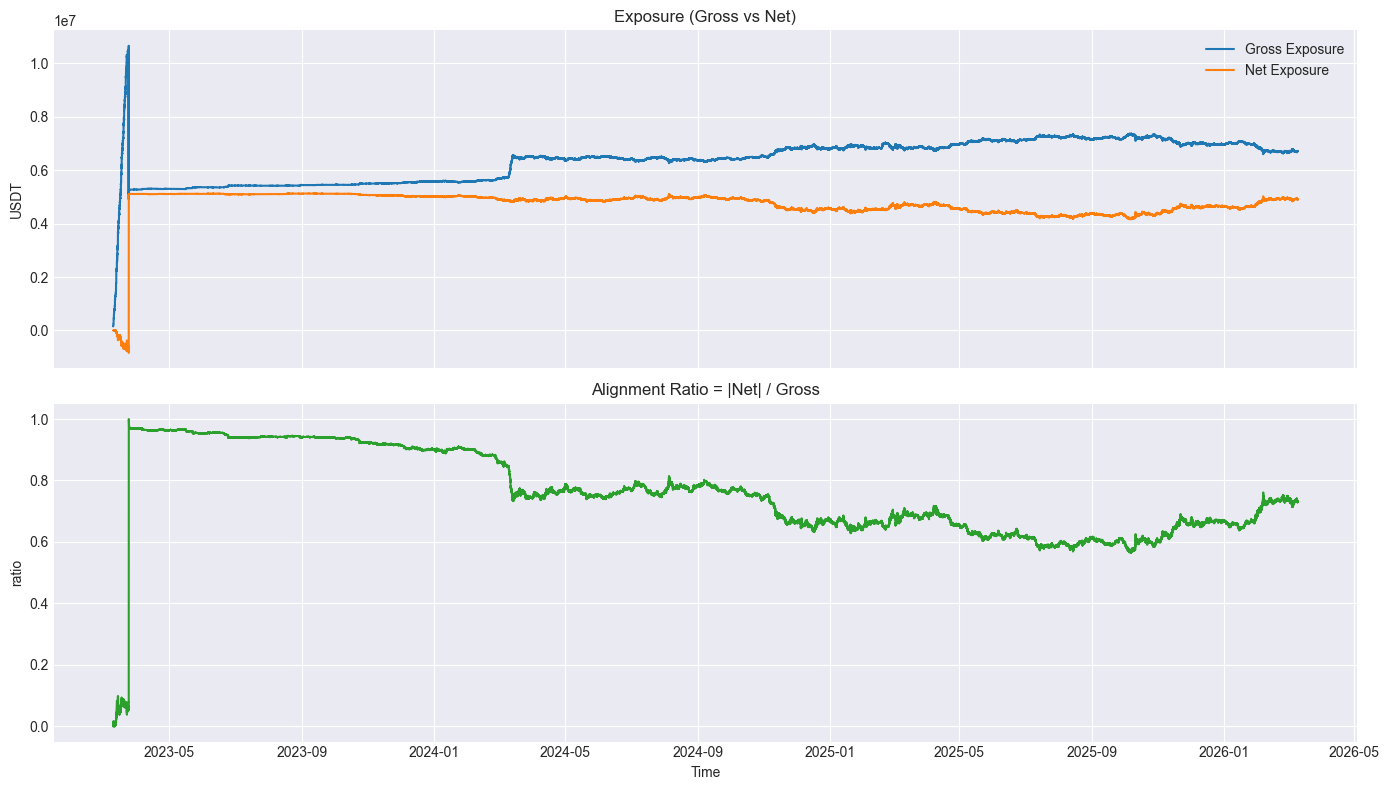

In [22]:
pos = tables['Position.arrow']
if pos is None or len(pos) == 0:
    print('Position.arrow is empty.')
else:
    p = pos.copy()
    p['timestamp'] = pd.to_numeric(p['timestamp'], errors='coerce')
    p['notional'] = pd.to_numeric(p['notional'], errors='coerce')
    p['is_long'] = p['is_long'].astype(bool)
    p = p.dropna(subset=['timestamp', 'notional', 'symbol']).sort_values(['timestamp', 'symbol'])

    # 每個 timestamp+symbol 保留最後一筆，避免同時間多筆快照重複計算
    p = p.groupby(['timestamp', 'symbol'], as_index=False).tail(1).copy()
    p['signed_notional'] = np.where(p['is_long'], p['notional'], -p['notional'])

    exp = p.groupby('timestamp', as_index=False).agg(
        net_exposure=('signed_notional', 'sum'),
        gross_exposure=('notional', lambda s: np.abs(s).sum())
    )
    exp['alignment_ratio'] = np.where(exp['gross_exposure'] > 1e-12, np.abs(exp['net_exposure']) / exp['gross_exposure'], np.nan)
    exp['dt'] = pd.to_datetime(exp['timestamp'], unit='ms', utc=True)

    exp_stats = exp[['net_exposure', 'gross_exposure', 'alignment_ratio']].describe(percentiles=[0.5, 0.9, 0.99]).T
    display(exp_stats)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(exp['dt'], exp['gross_exposure'], label='Gross Exposure', color='tab:blue')
    axes[0].plot(exp['dt'], exp['net_exposure'], label='Net Exposure', color='tab:orange')
    axes[0].set_title('Exposure (Gross vs Net)')
    axes[0].set_ylabel('USDT')
    axes[0].legend()

    axes[1].plot(exp['dt'], exp['alignment_ratio'], color='tab:green')
    axes[1].set_title('Alignment Ratio = |Net| / Gross')
    axes[1].set_ylabel('ratio')
    axes[1].set_xlabel('Time')

    plt.tight_layout()
    plt.show()

## 9) Mark-Index Guard 覆蓋率檢查

這段會讀 config 的 guard 門檻，估計市場落在：
- 正常區
- soft derisk 區
- hard guard 區
的時間占比。

用途：
- 檢查門檻是否過緊（長時間 hard）
- 或過鬆（幾乎永遠正常）

In [23]:
cfg = json.loads(config_path.read_text(encoding='utf-8')) if config_path.exists() else {}
signal_cfg = cfg.get('signal', {})
risk_cfg = cfg.get('risk', {})

soft_start = float(signal_cfg.get('mark_index_soft_derisk_start_bps', risk_cfg.get('mark_index_soft_derisk_start_bps', 0.0)) or 0.0)
soft_full = float(signal_cfg.get('mark_index_soft_derisk_full_bps', risk_cfg.get('mark_index_soft_derisk_full_bps', 0.0)) or 0.0)
hard = float(signal_cfg.get('mark_index_hard_exit_bps', risk_cfg.get('mark_index_hard_guard_bps', 0.0)) or 0.0)

mi = basis_df[['ts', 'dt', 'mark_index_bps']].dropna().copy()
mi['abs_bps'] = mi['mark_index_bps'].abs()

mi['zone'] = 'normal'
if soft_start > 0:
    mi.loc[mi['abs_bps'] >= soft_start, 'zone'] = 'soft'
if hard > 0:
    mi.loc[mi['abs_bps'] >= hard, 'zone'] = 'hard'

zone_ratio = mi['zone'].value_counts(normalize=True).rename('ratio').reset_index().rename(columns={'index': 'zone'})
zone_count = mi['zone'].value_counts().rename('count').reset_index().rename(columns={'index': 'zone'})
zone = zone_ratio.merge(zone_count, on='zone', how='outer').fillna(0)

print('soft_start_bps =', soft_start)
print('soft_full_bps  =', soft_full)
print('hard_bps       =', hard)
zone

soft_start_bps = 50.0
soft_full_bps  = 150.0
hard_bps       = 300.0


,zone,ratio,count
0,normal,0.999996,1175863
1,soft,0.000004,5
